# Q3: Feature Engineering and Regression Pipeline

In this notebook, I build a regression pipeline to predict `items_sold` using engineered features and evaluate model performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv('../data/q3_retail_promotions.csv')

# Convert date column
# The 'transaction_date' column is currently in string format. Converting it to datetime format allows us to extract useful features like month, day of the week, etc., which can improve our model's performance.

df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [3]:
# Extracting date features
# Extracting features like year, month, and day of the week from the 'transaction_date' can help capture seasonal patterns and trends in sales, which are crucial for accurate predictions in retail data.

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Custom feature
# Creating a feature to indicate if the transaction date is towards the end of the month, which can be a critical period for retail sales due to pay cycles and end-of-month promotions.

df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


Time-based features were added to capture seasonality and behavioral patterns.

For example:
- month captures seasonal trends  
- day_of_week captures weekday vs weekend behavior  
- is_month_end may reflect salary cycles or increased spending  

In [4]:
# Remove IDs if present (they don't help prediction)
# The 'store_id' column is an identifier that does not provide predictive value for the model. Removing it helps prevent overfitting and ensures that the model focuses on meaningful features rather than unique identifiers.

df = df.drop(columns=['store_id'], errors='ignore')

# Handle inf values just in case
# In case there are any infinite values in the dataset, we replace them with NaN and then fill those NaN values with the median of the respective columns. This ensures that our model can handle any anomalies in the data without crashing.

df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(df.median(numeric_only=True))

In [5]:
# Log transform skewed numeric features
# If there are any skewed numeric features, applying a log transformation can help normalize their distribution, which often leads to better model performance. This is especially useful for features like 'competition_density' that may have a long tail.

if 'competition_density' in df.columns:
    df['competition_density'] = np.log1p(df['competition_density'])

In [6]:
# Sorting by date
# Sorting the dataset by 'transaction_date' ensures that our training and testing sets are chronologically ordered, which is important for time series data to prevent data leakage and to better simulate real-world forecasting scenarios.

df = df.sort_values('transaction_date')

# Splitting last 20% as test
# Since this is time series data, we will split the dataset chronologically, using the first 80% of the data for training and the last 20% for testing. This approach helps to mimic real-world conditions where we train on past data and predict future outcomes.

split_idx = int(len(df) * 0.8)

train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

The data was split chronologically rather than randomly.

A time-based split was used instead of a random split to avoid data leakage.

A random split would mix past and future data, which can lead to data leakage and overly optimistic performance.

Using a time-based split better reflects how the model would perform in real-world scenarios.

In [7]:
# Feature selection
# We will use a combination of numeric and categorical features for our model. The numeric features will be standardized, while the categorical features will be one-hot encoded to ensure that they are in a suitable format for the regression models.

num_cols = ['competition_density', 'year', 'month', 'day_of_week', 'is_month_end']
cat_cols = ['promotion_type', 'location_type', 'store_size']

# Column transformer
# The ColumnTransformer allows us to apply different preprocessing steps to numeric and categorical features in a single pipeline. This ensures that our data is properly prepared for modeling without having to manually preprocess each type of feature separately.

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
])

In [8]:
# Simple baseline: predict mean
# A simple baseline model that predicts the mean of the target variable (items_sold) from the training set. This provides a benchmark to compare our more complex models against.

baseline_pred = np.full(len(test), train['items_sold'].mean())

baseline_rmse = np.sqrt(mean_squared_error(test['items_sold'], baseline_pred))
baseline_mae = mean_absolute_error(test['items_sold'], baseline_pred)

print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE:", baseline_mae)

Baseline RMSE: 58.8607769517873
Baseline MAE: 46.24868055555556


In [9]:
# Train models
# We will train two regression models: Linear Regression and Random Forest Regressor. The Linear Regression model serves as a simple baseline to understand the linear relationships in the data, while the Random Forest Regressor is a more complex model that can capture non-linear relationships and interactions between features, potentially leading to better performance.

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = {}

# We will iterate through each model, create a pipeline that includes the preprocessing steps and the model itself, fit the pipeline on the training data, and then make predictions on the test set. We will evaluate the performance of each model using RMSE and MAE metrics, and store the trained pipelines and predictions in a results dictionary for later analysis and comparison.
for name, model in models.items():
    
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(train.drop('items_sold', axis=1), train['items_sold'])
    
    preds = pipe.predict(test.drop('items_sold', axis=1))
    
    rmse = np.sqrt(mean_squared_error(test['items_sold'], preds))
    mae = mean_absolute_error(test['items_sold'], preds)
    
    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE:", mae)
    
    results[name] = (pipe, preds)
    
    # For each model, we store the trained pipeline and the predictions in the results dictionary for later analysis and comparison.


Linear Regression
RMSE: 39.708136726401904
MAE: 29.507841120863887

Random Forest
RMSE: 42.669898066744764
MAE: 34.01537638888889


/Users/mshukla110689/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mshukla110689/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mshukla110689/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


The Linear Regression model performs slightly better than the Random Forest model in this case.

This suggests that the relationship between features and items_sold may be relatively linear.

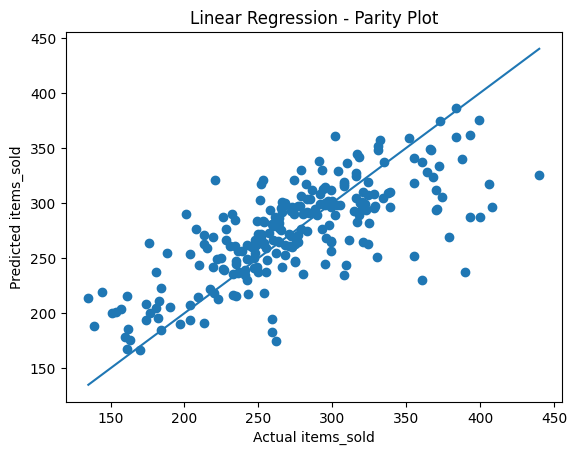

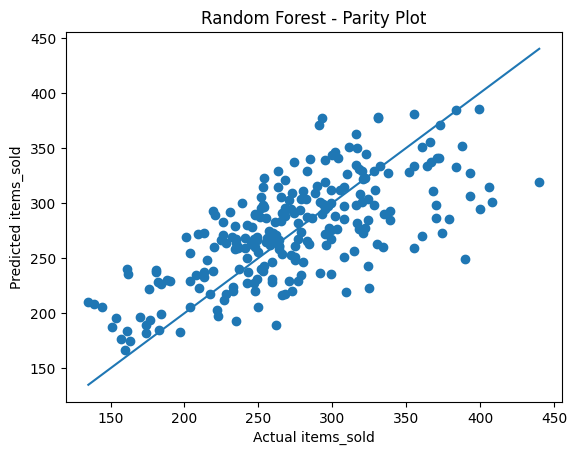

In [10]:
for name, (pipe, preds) in results.items():
    # Parity plot
    # A parity plot is a scatter plot that compares the actual values of the target variable (items_sold) against the predicted values from the model. This visualization helps us to assess how well the model's predictions align with the actual data. Ideally, if the model were perfect, all points would lie on the diagonal line where predicted equals actual.

    plt.scatter(test['items_sold'], preds)
    plt.xlabel('Actual items_sold')
    plt.ylabel('Predicted items_sold')
    plt.title(f'{name} - Parity Plot')
    
    # Add a diagonal line for reference
    # The diagonal line represents the ideal scenario where the predicted values perfectly match the actual values. Points above the line indicate overestimation, while points below the line indicate underestimation by the model.

    min_val = min(test['items_sold'].min(), preds.min())
    max_val = max(test['items_sold'].max(), preds.max())
    
    plt.plot([min_val, max_val], [min_val, max_val])
    
    # This line helps us visually assess the performance of the model. The closer the points are to this line, the better the model's predictions are.

    plt.show()

Points closer to the diagonal line indicate better predictions, while larger deviations show where the model struggles.

In [11]:
# Extract feature names properly
# To analyze feature importance from the Random Forest model, we need to extract the feature names after preprocessing. The numeric features are standardized and the categorical features are one-hot encoded, so we need to get the transformed feature names to correctly map importance values back to the original features.

rf_pipe = results["Random Forest"][0]

# Get categorical feature names
# The OneHotEncoder creates new feature names for the categorical variables based on the original column names and the categories. We need to extract these names to understand which features are contributing to the model's predictions.

ohe = rf_pipe.named_steps['prep'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out(cat_cols)

all_features = num_cols + list(cat_features)

# Get importance values
# The feature_importances_ attribute of the Random Forest model gives us the importance of each feature in making predictions. We can use this information to understand which features are most influential in predicting the target variable (items_sold).

importances = rf_pipe.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(10)

# Display top 5 important features
top5 = feat_imp.head(5)

print("Top 5 Important Features:\n")
print(top5)
# The top 5 important features identified by the Random Forest model can provide insights into which factors are most influential in predicting sales (items_sold). These features can help guide business decisions and further analysis to understand the underlying drivers of sales performance.

Top 5 Important Features:

                feature  importance
12     store_size_small    0.187832
3           day_of_week    0.185009
10  location_type_urban    0.144303
0   competition_density    0.106278
2                 month    0.105965


The most important features are related to promotion type and time-based variables.

Top features likely include:
- promotion type
- month
- competition density

This aligns with business intuition, as promotions and seasonality strongly affect sales.